In [1]:
import pandas
import openpyxl
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import copy

In [52]:
#Loading and sorting
df = pandas.read_excel('User Study Questionnaire (Respostas).xlsx')
# print(df.shape)

df = df.fillna(np.nan)
df = df.replace(['Strongly Disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly Agree'], [1, 2, 3, 4, 5])
df = df.replace(['1 (Strongly Disagree)', '2 (Disagree)', '3 (Neutral)', '4 (Agree)', '5 (Strongly Agree)'], [1, 2, 3, 4, 5])
drop_cols = df.columns
drop_cols = drop_cols[drop_cols.str.contains('Could you please tell us why?')]
df = df.drop(drop_cols, axis=1)
# print(df.columns)

nt_df = df[~df['Do you have any diagnosed mental health conditions?'].str.contains('ADHD/ADD')].reset_index()
adhd_df = df[df['Do you have any diagnosed mental health conditions?'].str.contains('ADHD/ADD')].reset_index()

general_questions = [
    'How often do you use AI Chatbots  (ChatGPT, Gemini, Claude, etc.) for any purpose (research, assistance, conversation, etc.)? ',
    'For what purposes do you use AI Chatbots?',
    'Rate your preference in communication style when conversing with an AI Chatbot for emotional regulation support.  [Friendly and empathetic]',
    'Rate your preference in communication style when conversing with an AI Chatbot for emotional regulation support.  [Clinical and professional]',
    'Rate your preference in communication style when conversing with an AI Chatbot for emotional regulation support.  [Direct and action-oriented]',
    'Rate how much you agree with the following statement: “The conversational tone of an AI Chatbot is a major factor in whether I find it helpful for emotional regulation.” '
]

scenario_questions = [
    'Rate how much you agree with the following statement: “I found the response of the chatbot helpful”',
    'Rate how much you agree with the following statement: “I trust the chatbot and it\'s response”',
    'Rate how much you agree with the following statement: “I found the response of the chatbot comforting”',
    'Rate how much you agree with the following statement: “I am personally comfortable with asking a/the chatbot questions of this nature”',
]

remapping = {
    1: {'Friendly': None, 'Professional': 2},
    2: {'Friendly': 3, 'Professional': 4},
    3: {'Friendly': 6, 'Professional': 5},
    4: {'Friendly': 7, 'Professional': 8},
    5: {'Friendly': 10, 'Professional': 9},
}

def append_num(src_str, num):
    return src_str + "  " + str(num) if num is not None else src_str + " "

def split_compound_responses(data):
    data_dict = {}
    value_counts = data.value_counts()
    for entry in value_counts.index:
        keys = entry.split(',')
        for key in keys:
            if not (key in data_dict.keys()):
                data_dict[key] = 0
    # print(data_dict)

    for entry in data:
        if type(entry) == str:
            keys = entry.split(',')
            for key in keys:
                data_dict[key] += 1

    return data_dict

responses = {'nt': copy.deepcopy(remapping), 'adhd': copy.deepcopy(remapping)}
general_responses = {'nt': {}, 'adhd': {}}
dfs = {'nt': nt_df, 'adhd': adhd_df}

for scenario in remapping:
    for response in remapping[scenario]:
        for cohort in responses:
            resp_df = pandas.DataFrame(scenario_questions)
            for question in scenario_questions:
                qstring = append_num(question, remapping[scenario][response])
                resp_df[question] = dfs[cohort][qstring]
            responses[cohort][scenario][response] = resp_df

for cohort in responses:
    for question in general_questions:
        if question == 'For what purposes do you use AI Chatbots?':
            print(dfs[cohort][question])
            general_responses[cohort][question] = split_compound_responses(dfs[cohort][question])
        else:
            general_responses[cohort][question] = list(dfs[cohort][question])

display(responses)

# for cohort in responses:
#     for scenario in remapping:
#         for tone in remapping[scenario]:
#             for question in scenario_questions:
#                 print(type(responses[cohort][scenario][tone][question]))
#                 print(list(responses[cohort][scenario][tone][question]))
#             print(f"Everything for {tone}")

0            Education, Work
1    Education, Personal use
2            Education, Work
3                  Education
Name: For what purposes do you use AI Chatbots?, dtype: str
0    Work, Personal use, Emotional Support
1                                Education
2            Education, Work, Personal use
3            Education, Work, Personal use
Name: For what purposes do you use AI Chatbots?, dtype: str


{'nt': {1: {'Friendly':                                                    0  \
   0  Rate how much you agree with the following sta...   
   1  Rate how much you agree with the following sta...   
   2  Rate how much you agree with the following sta...   
   3  Rate how much you agree with the following sta...   
   
     Rate how much you agree with the following statement: “I found the response of the chatbot helpful”  \
   0                                                  4                                                    
   1                                                  5                                                    
   2                                                  3                                                    
   3                                                  5                                                    
   
     Rate how much you agree with the following statement: “I trust the chatbot and it's response”  \
   0                              

In [ ]:
#Ordinal data, so non-parametric tests required
#Few samples so no chi-squared
#Wilcoxon signed is most appropriate for paired data/within group testing (friendly vs professional tone)
#See if people of a certain cohort have a preference for chatbot tone

#For all scenarios
for cohort in responses:
    ratings = {}
    for question in scenario_questions:
        ratings[question] = {}
        for tone in remapping[1]:
            ratings[question][tone] = []
    for scenario in remapping:
        for tone in remapping[scenario]:
            for question in scenario_questions:
                # print(list(responses[cohort][scenario][tone][question]))
                ratings[question][tone] += list(responses[cohort][scenario][tone][question])
            # print(f"Everything for {tone}")

    for key in ratings:
        print(f"{cohort} people for {key} on all scenarios together")
        for subkey in ratings[key]:
            print(f"{subkey} sum: {sum(ratings[key][subkey])}")
        wilcoxon_stats = scipy.stats.wilcoxon(ratings[key]['Friendly'], ratings[key]['Professional'])
        print(f"Wilcoxon statistic: {wilcoxon_stats.statistic}, p-value: {wilcoxon_stats.pvalue}")
    print("_____________________________________________________________________\n")

#Per scenario
for cohort in responses:
    for scenario in remapping:
        ratings = {}
        for question in scenario_questions:
            ratings[question] = {}
            for tone in remapping[1]:
                ratings[question][tone] = []
        for tone in remapping[scenario]:
            for question in scenario_questions:
                # print(list(responses[cohort][scenario][tone][question]))
                ratings[question][tone] += list(responses[cohort][scenario][tone][question])
            # print(f"Everything for {tone}")

        for key in ratings:
            print(f"{cohort} people for scenario {scenario}, {key}")
            for subkey in ratings[key]:
                print(f"{subkey} sum: {sum(ratings[key][subkey])}")
            wilcoxon_stats = scipy.stats.wilcoxon(ratings[key]['Friendly'], ratings[key]['Professional'])
            print(f"Wilcoxon statistic: {wilcoxon_stats.statistic}, p-value: {wilcoxon_stats.pvalue}")
        print("____________________________________________________________________\n")

nt people for Rate how much you agree with the following statement: “I found the response of the chatbot helpful” on all scenarios together
Friendly sum: 80
Professional sum: 84
Wilcoxon statistic: 25.0, p-value: 0.4679768755031235
nt people for Rate how much you agree with the following statement: “I trust the chatbot and it's response” on all scenarios together
Friendly sum: 64
Professional sum: 70
Wilcoxon statistic: 16.0, p-value: 0.23180855179227267
nt people for Rate how much you agree with the following statement: “I found the response of the chatbot comforting” on all scenarios together
Friendly sum: 89
Professional sum: 74
Wilcoxon statistic: 4.5, p-value: 0.00814116439452509
nt people for Rate how much you agree with the following statement: “I am personally comfortable with asking a/the chatbot questions of this nature” on all scenarios together
Friendly sum: 47
Professional sum: 53
Wilcoxon statistic: 0.0, p-value: 0.0633177868300456
________________________________________

a:\Documents\Aarthi\Uni\Lisbon\Y1\S2\Methods and Studies with Users\Project\MEU-project\.venv\Lib\site-packages\scipy\stats\_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


In [56]:
#Mann-Whitney U test is most appropriate for between group testing
#Check for differences between ADHD vs NT group. First by all scenarios for each question, then per scenario per question

# general_questions = [
#     'How often do you use AI Chatbots  (ChatGPT, Gemini, Claude, etc.) for any purpose (research, assistance, conversation, etc.)? ',
#     'For what purposes do you use AI Chatbots?',
#     'Rate your preference in communication style when conversing with an AI Chatbot for emotional regulation support.  [Friendly and empathetic]',
#     'Rate your preference in communication style when conversing with an AI Chatbot for emotional regulation support.  [Clinical and professional]',
#     'Rate your preference in communication style when conversing with an AI Chatbot for emotional regulation support.  [Direct and action-oriented]',
#     'Rate how much you agree with the following statement: “The conversational tone of an AI Chatbot is a major factor in whether I find it helpful for emotional regulation.” '
# ]

for question in general_responses['adhd']:
    if question in general_questions[2:]:
        mwu_stat = scipy.stats.mannwhitneyu(general_responses['nt'][question], general_responses['adhd'][question])
        print(f"For {question}: MWU stat: {mwu_stat.statistic}, p-value {mwu_stat.pvalue}")
    elif question == 'For what purposes do you use AI Chatbots?':
        # print(general_responses['nt'][question])
        for application in general_responses['nt'][question]:
            mwu_stat = scipy.stats.mannwhitneyu(general_responses['nt'][question][application], general_responses['adhd'][question][application])
            print(f"For chatbot usage for {application}: MWU stat: {mwu_stat.statistic}, p-value {mwu_stat.pvalue}")

print("\n\n")

#For all scenarios
# for cohort in responses:
print("Across all scenarios:")
ratings = {}
for cohort in responses:
    ratings[cohort] = {}
    for question in scenario_questions:
        ratings[cohort][question] = {}
        for tone in remapping[1]:
            ratings[cohort][question][tone] = []
for scenario in remapping:
    for tone in remapping[scenario]:
        for question in scenario_questions:
            # print(list(responses[cohort][scenario][tone][question]))
            for cohort in responses:
                ratings[cohort][question][tone] += list(responses[cohort][scenario][tone][question])

for question in scenario_questions:
    for tone in remapping[1]:
        mwu_stat = scipy.stats.mannwhitneyu(ratings['nt'][question][tone], ratings['adhd'][question][tone])
        print(f"For {question} with {tone} tone: MWU stat: {mwu_stat.statistic}, p-value {mwu_stat.pvalue}")
    print("___________________________________________________________________________")
print("___________________________________________________________________________")

for scenario in remapping:
    ratings = {}
    for cohort in responses:
        ratings[cohort] = {}
        for question in scenario_questions:
            ratings[cohort][question] = {}
            for tone in remapping[1]:
                ratings[cohort][question][tone] = []
    for tone in remapping[scenario]:
        for question in scenario_questions:
            # print(list(responses[cohort][scenario][tone][question]))
            for cohort in responses:
                ratings[cohort][question][tone] += list(responses[cohort][scenario][tone][question])

    print(f"In scenario {scenario}")
    for question in scenario_questions:
        for tone in remapping[1]:
            mwu_stat = scipy.stats.mannwhitneyu(ratings['nt'][question][tone], ratings['adhd'][question][tone])
            print(f"For {question} with {tone} tone: MWU stat: {mwu_stat.statistic}, p-value {mwu_stat.pvalue}")
        print("___________________________________________________________________________")
    print("___________________________________________________________________________")

For chatbot usage for Education: MWU stat: 1.0, p-value 1.0
For chatbot usage for  Work: MWU stat: 0.5, p-value 1.0
For chatbot usage for  Personal use: MWU stat: 0.0, p-value 1.0
For Rate your preference in communication style when conversing with an AI Chatbot for emotional regulation support.  [Friendly and empathetic]: MWU stat: 8.0, p-value 1.0
For Rate your preference in communication style when conversing with an AI Chatbot for emotional regulation support.  [Clinical and professional]: MWU stat: 12.0, p-value 0.2784463052387641
For Rate your preference in communication style when conversing with an AI Chatbot for emotional regulation support.  [Direct and action-oriented]: MWU stat: 4.0, p-value 0.1813582759043133
For Rate how much you agree with the following statement: “The conversational tone of an AI Chatbot is a major factor in whether I find it helpful for emotional regulation.” : MWU stat: 8.0, p-value 1.0



Across all scenarios:
For Rate how much you agree with the fol

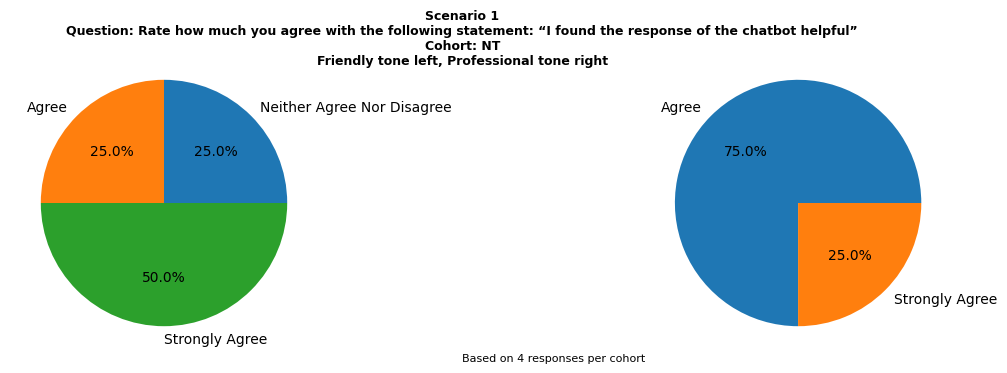

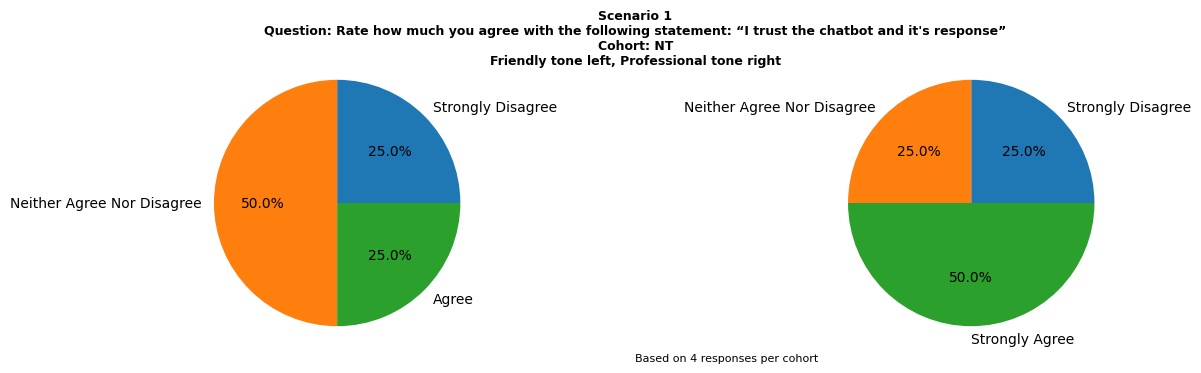

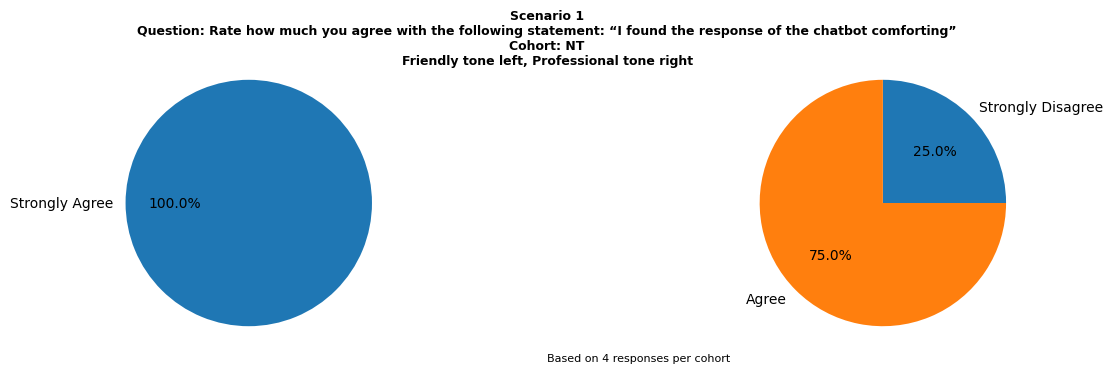

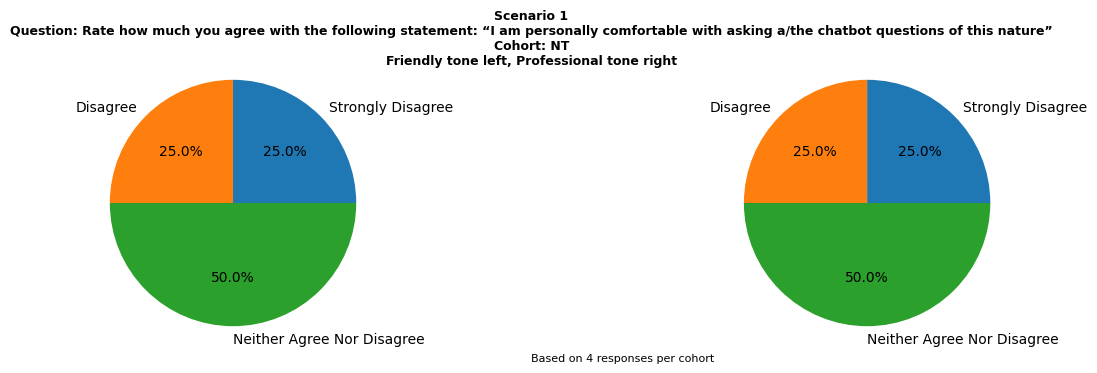

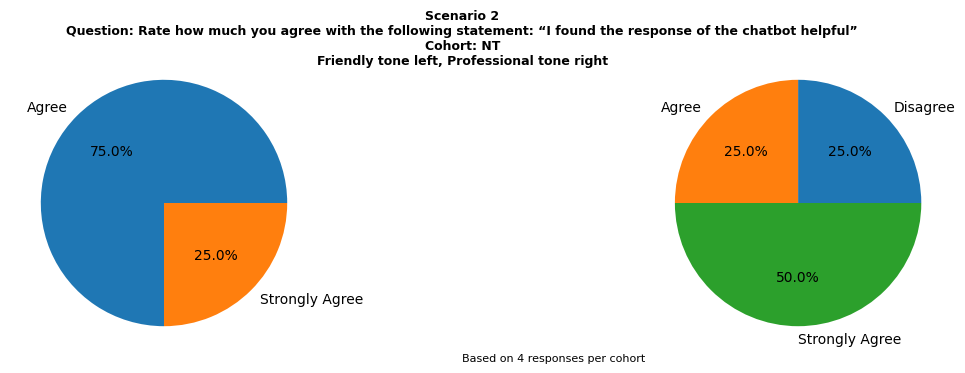

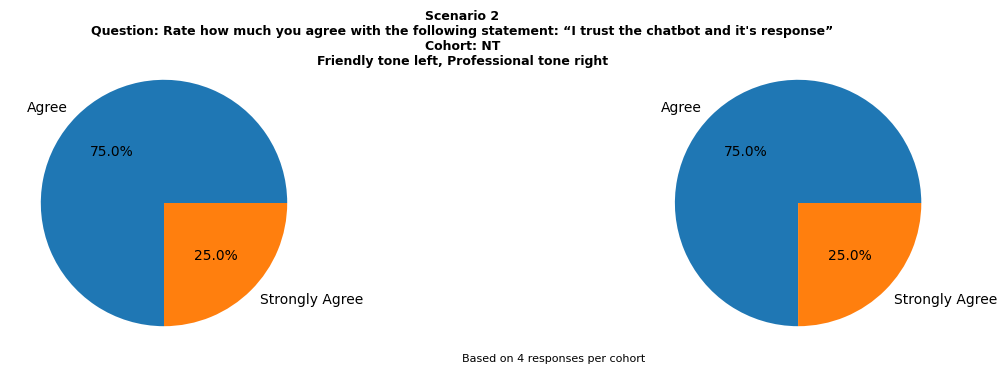

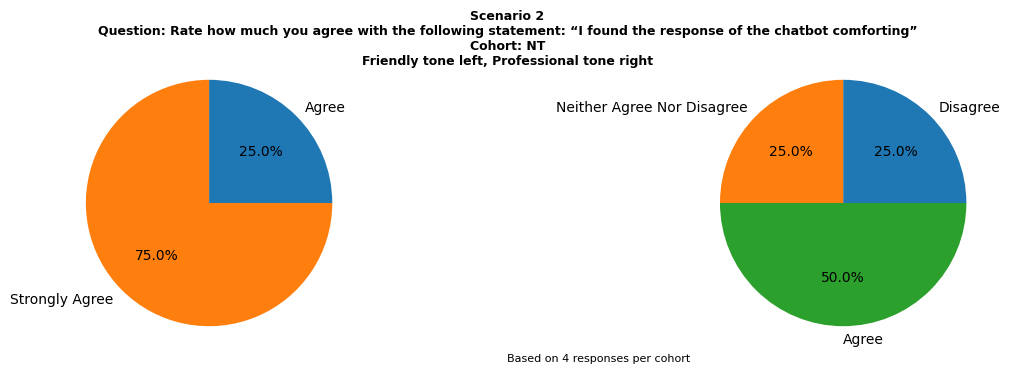

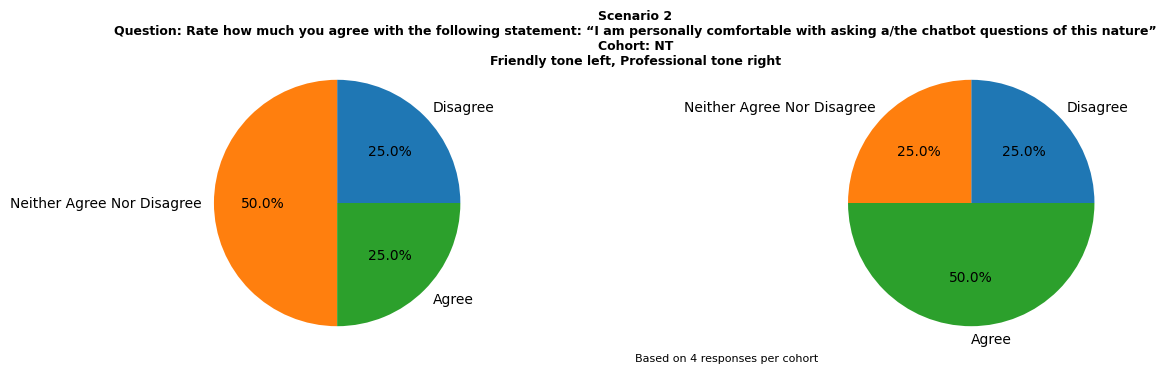

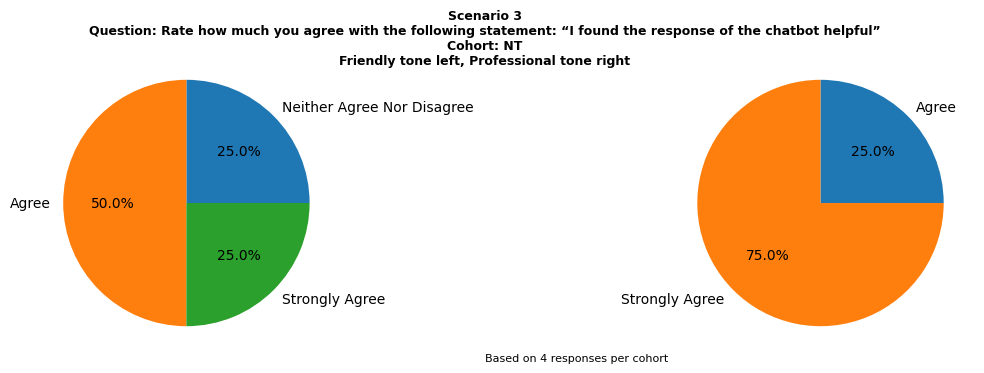

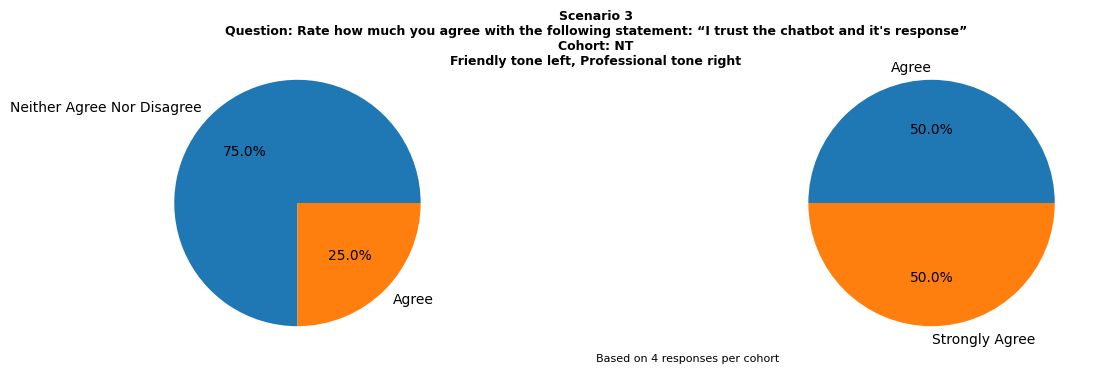

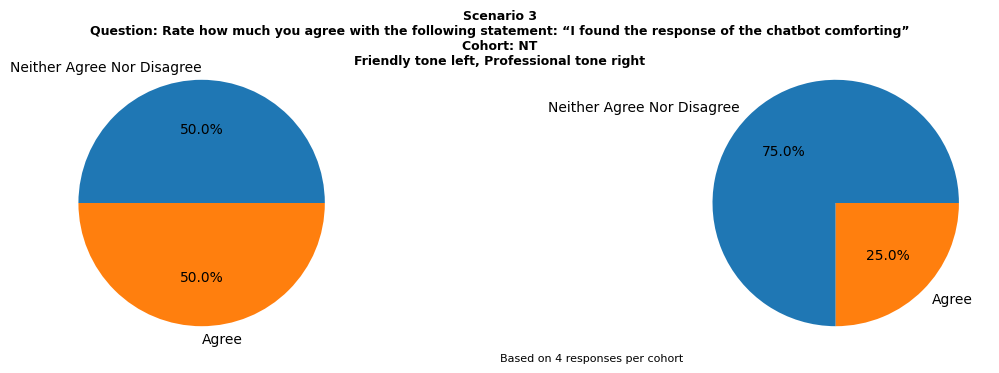

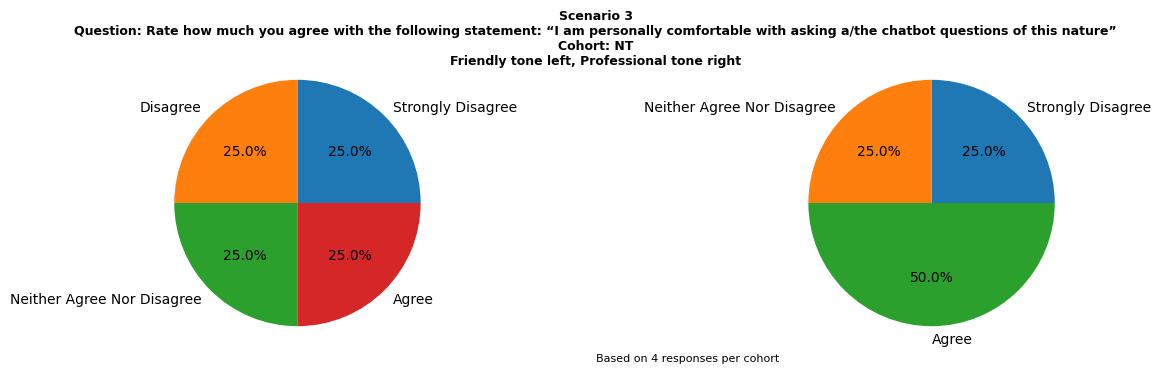

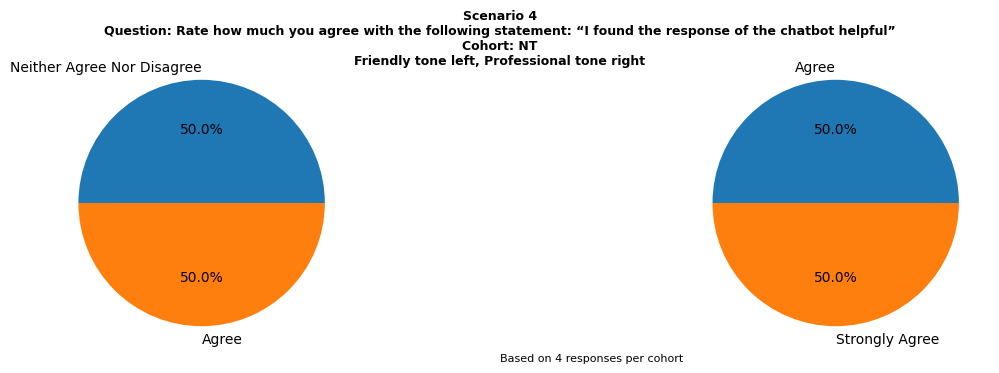

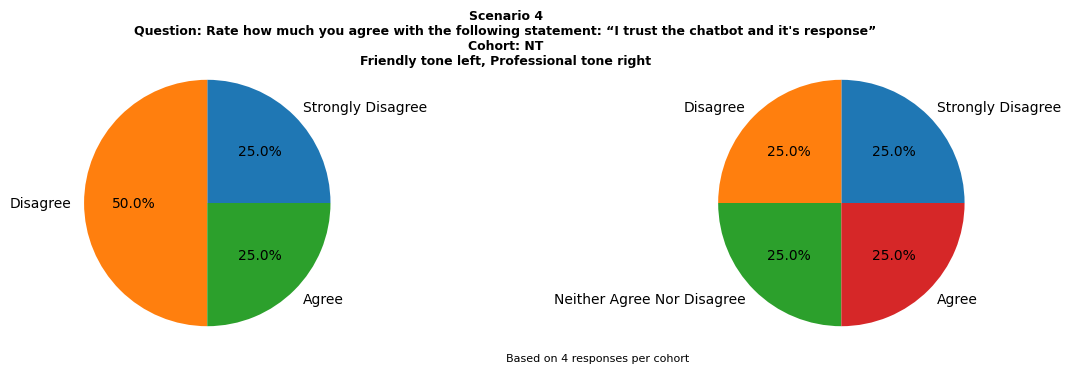

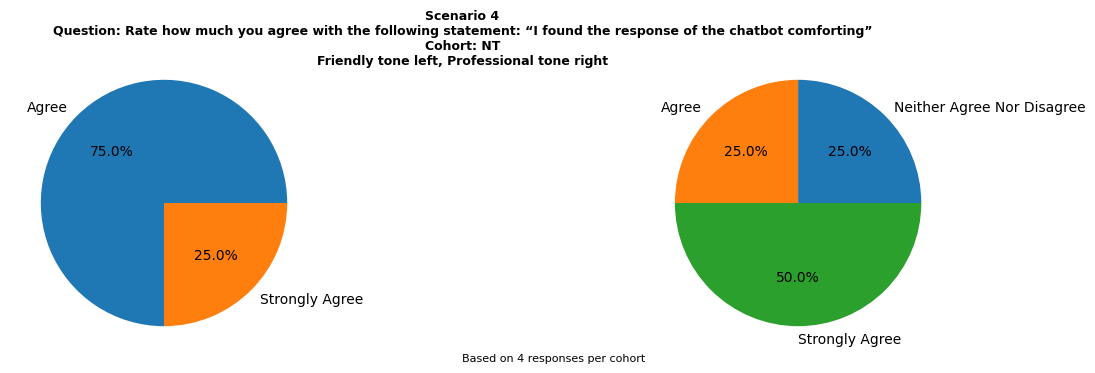

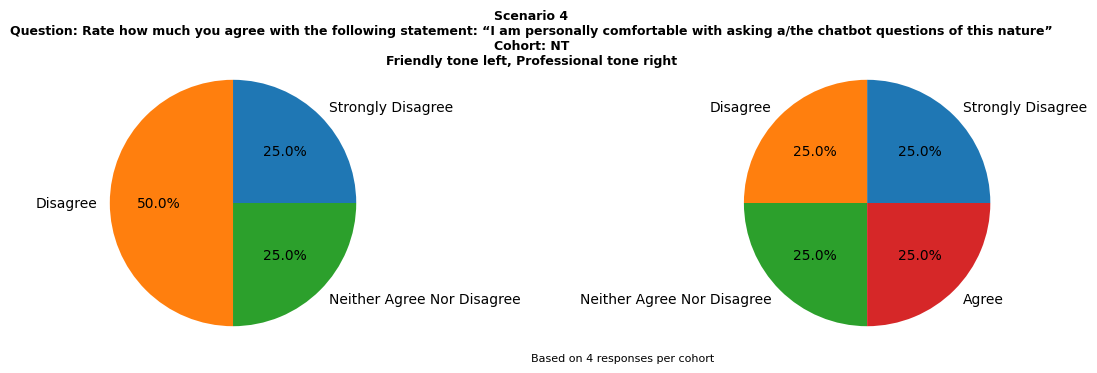

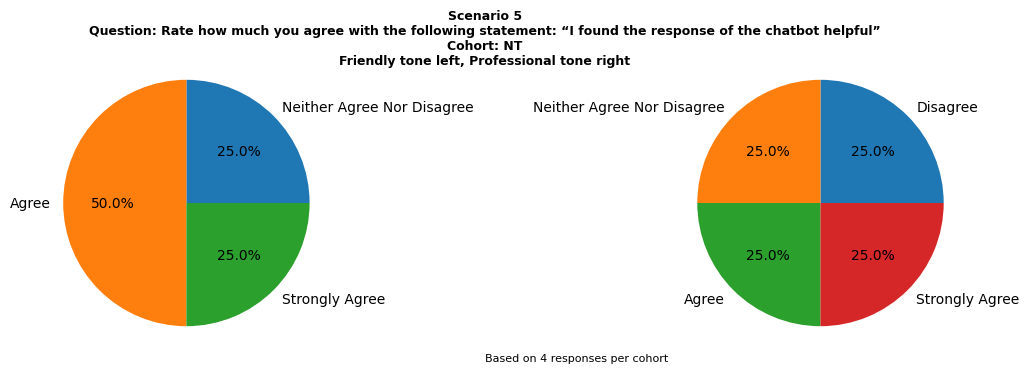

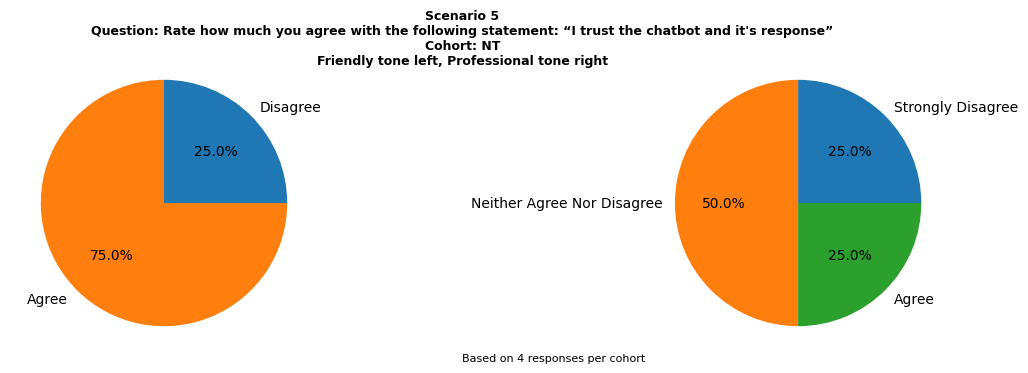

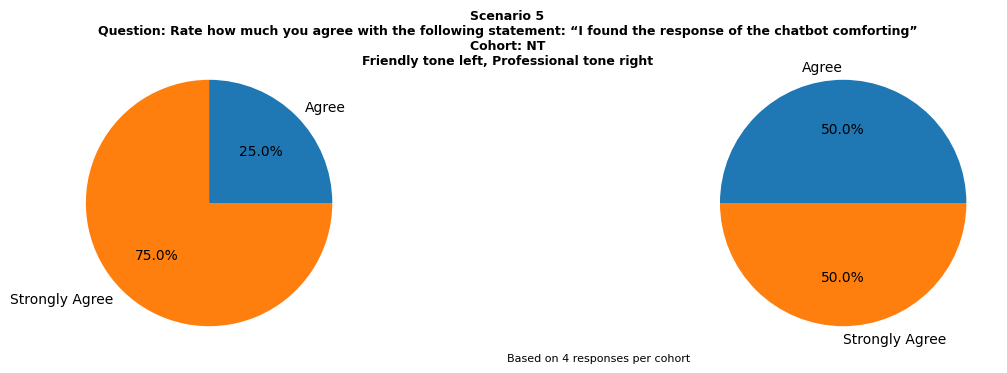

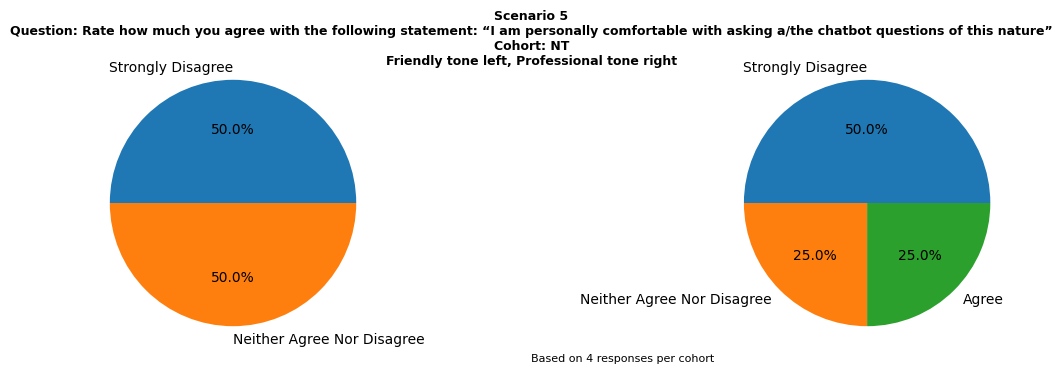

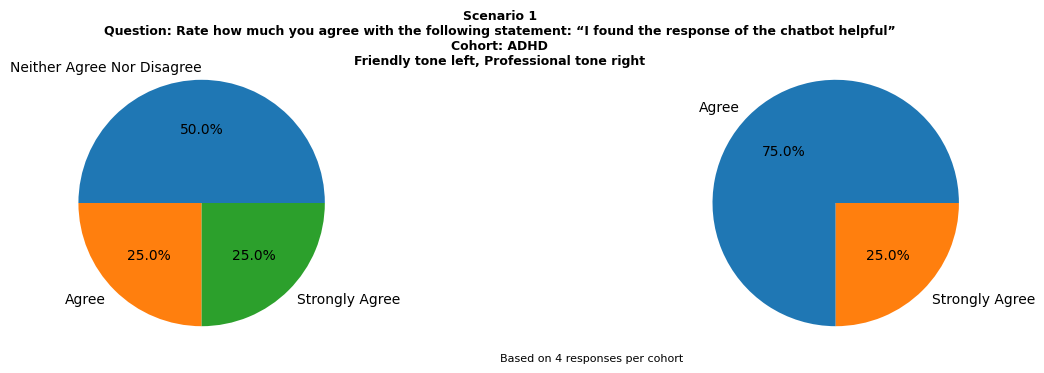

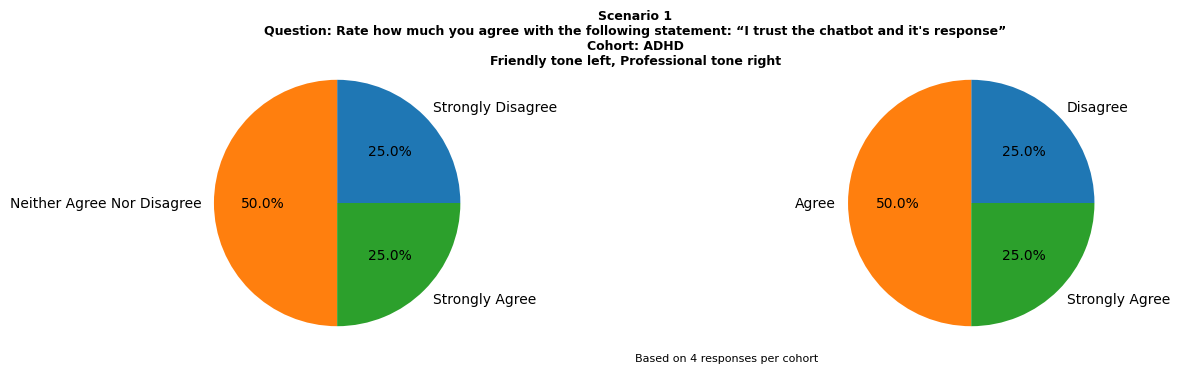

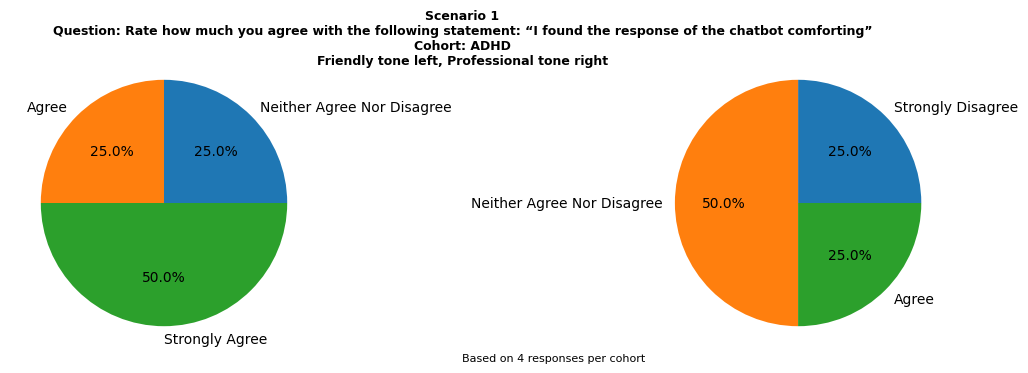

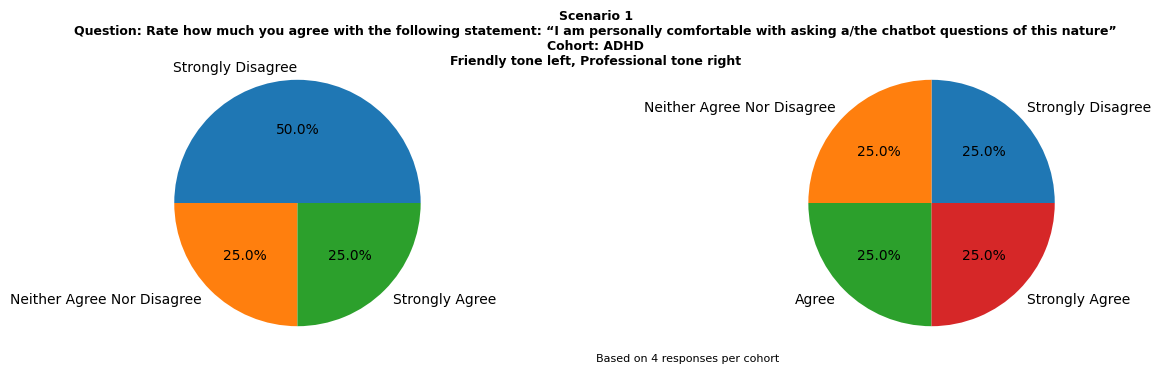

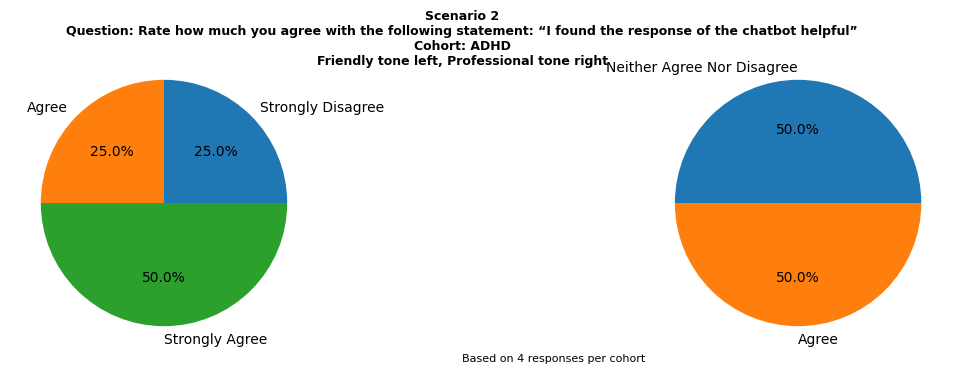

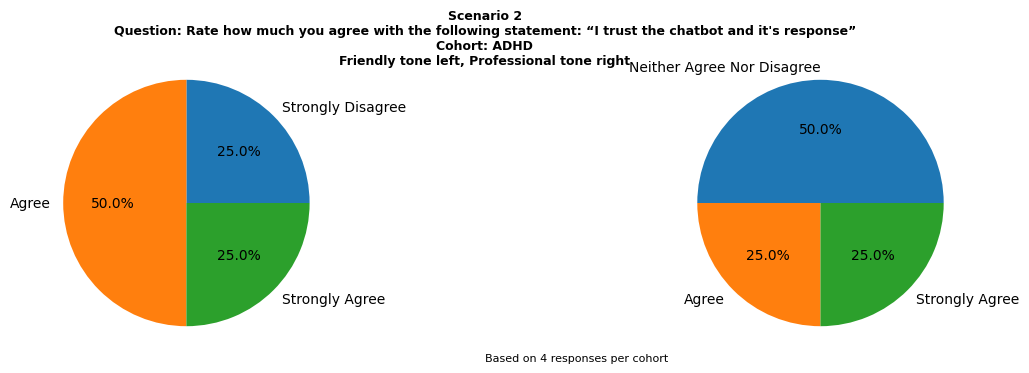

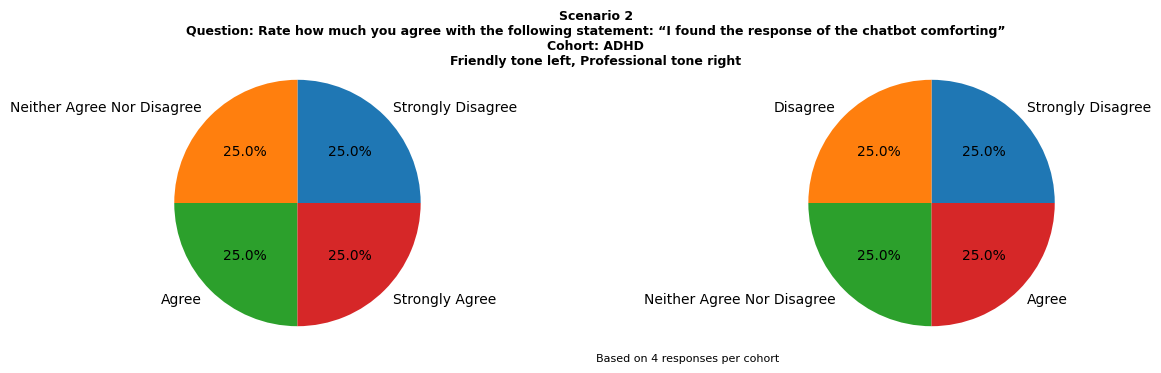

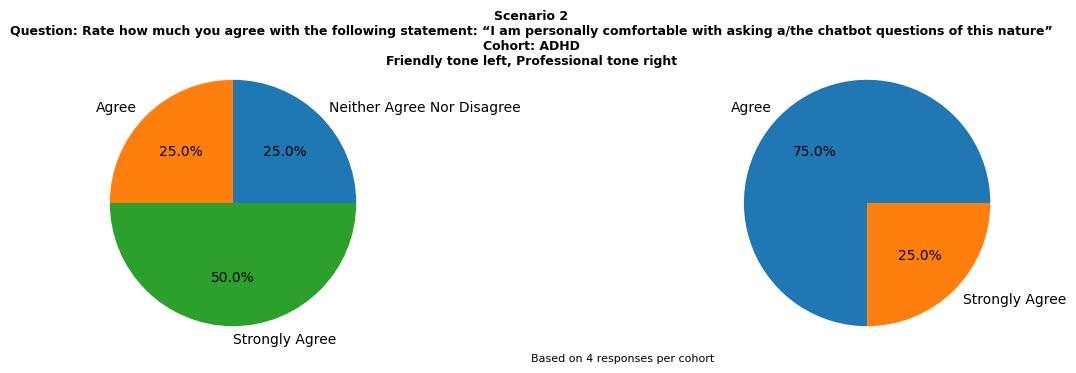

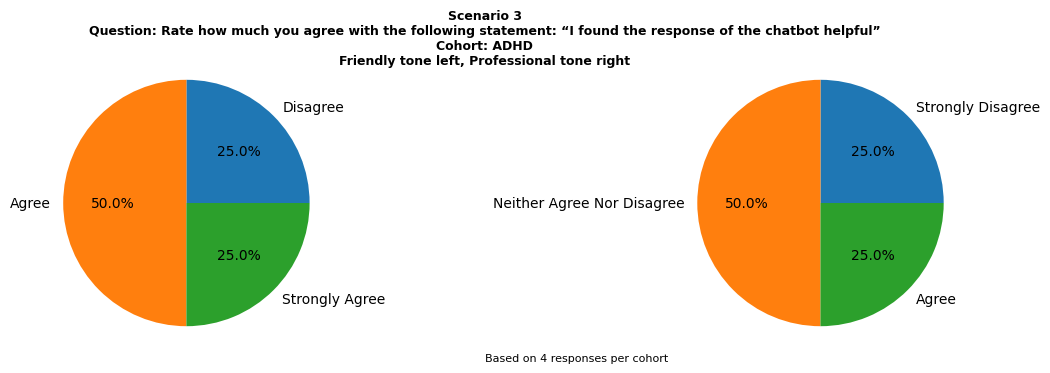

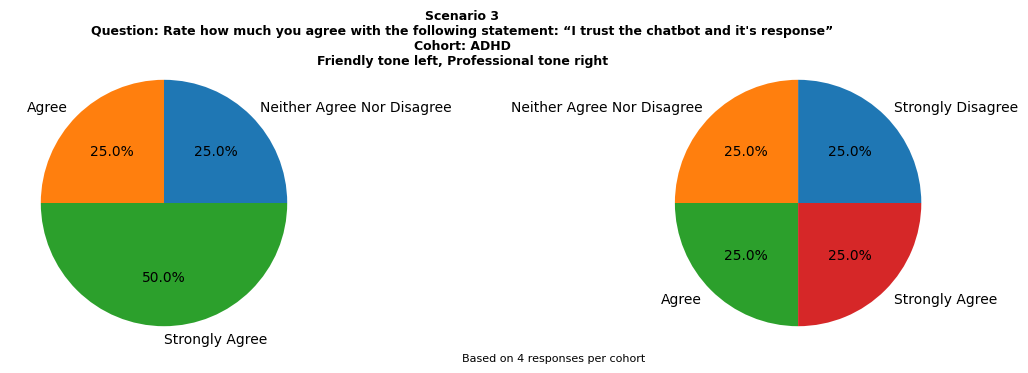

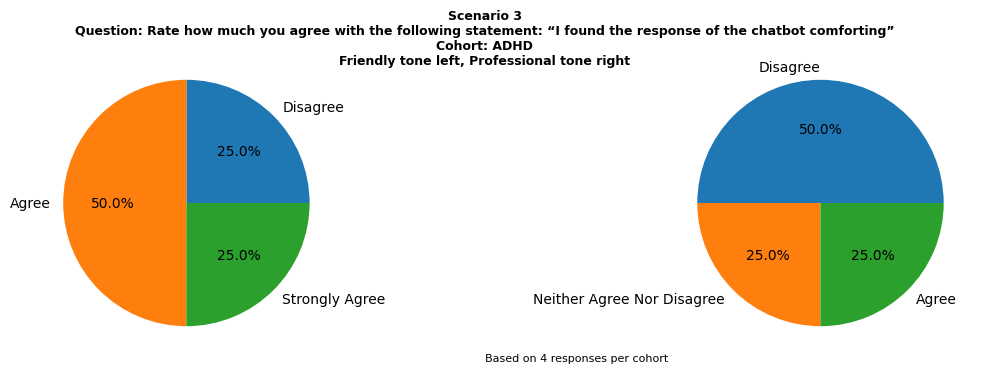

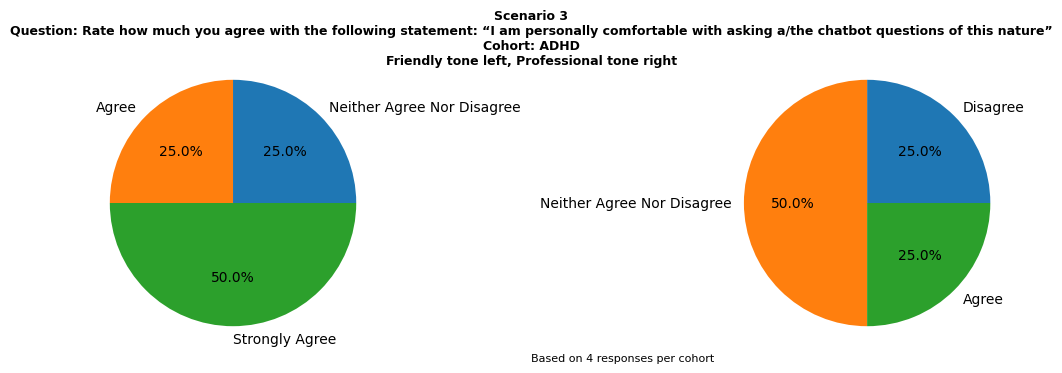

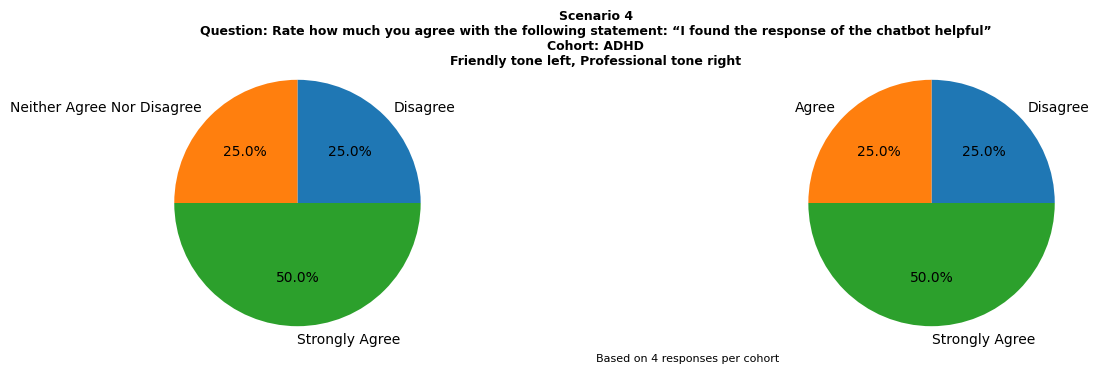

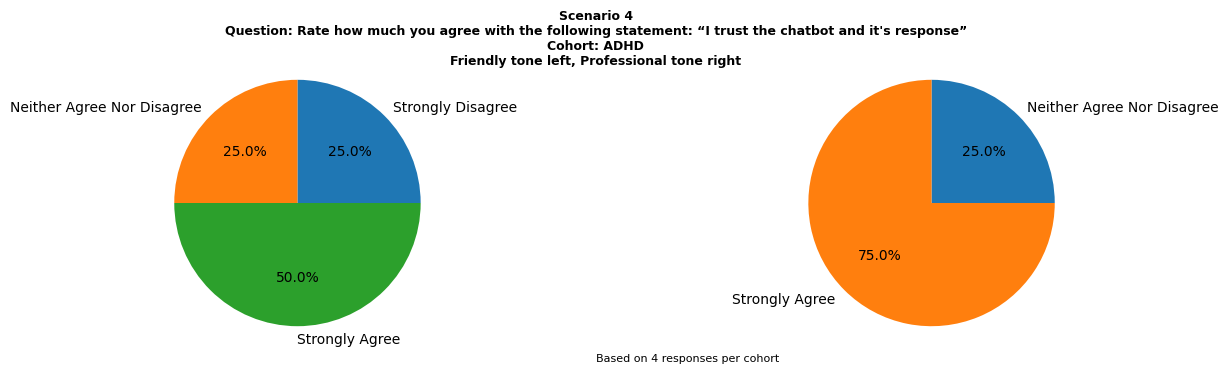

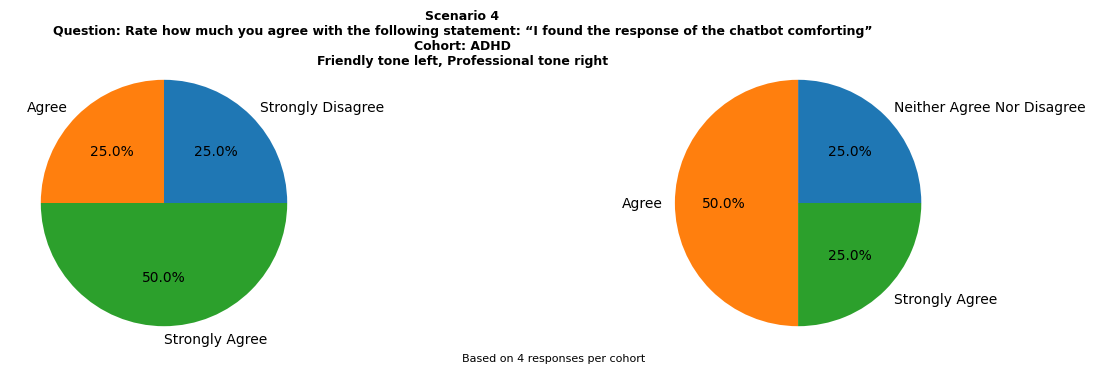

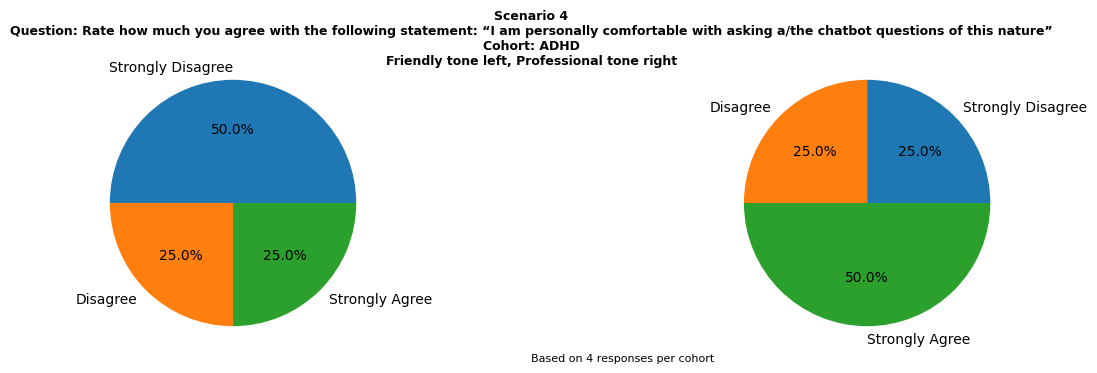

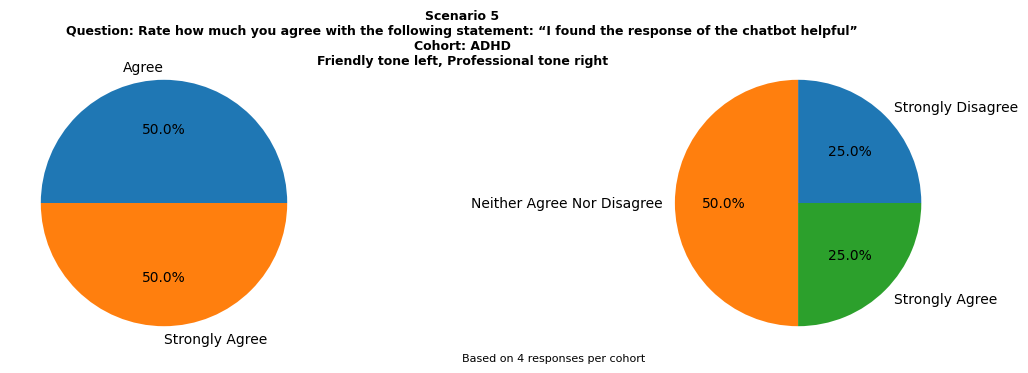

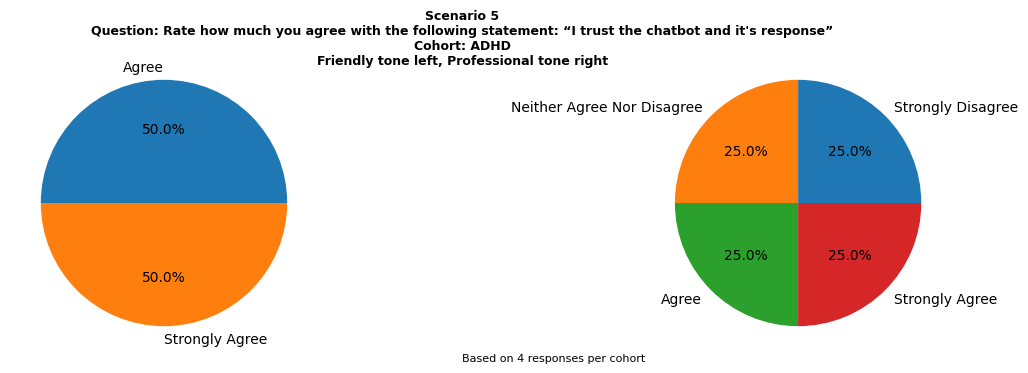

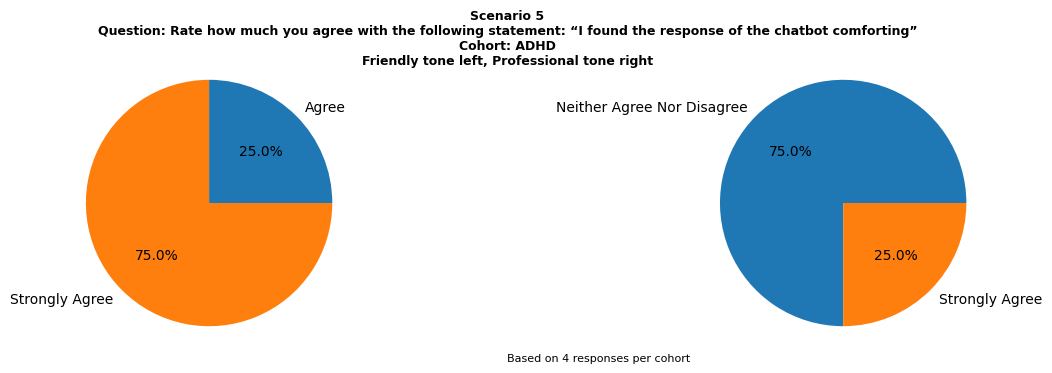

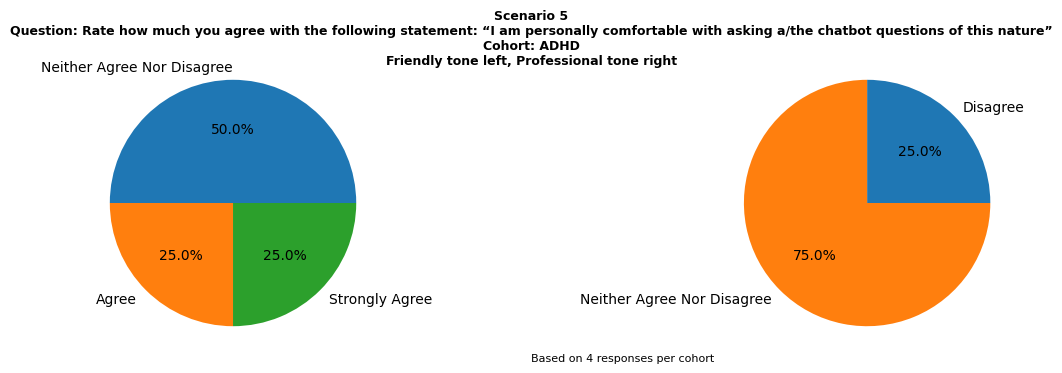

In [ ]:
def likert_count(array_in):
    mapping = {
        1: "Strongly Disagree",
        2: "Disagree",
        3: "Neither Agree Nor Disagree",
        4: "Agree",
        5: "Strongly Agree",
    }
    ret = {
        "Strongly Disagree": 0,
        "Disagree": 0,
        "Neither Agree Nor Disagree": 0,
        "Agree": 0,
        "Strongly Agree": 0,
    }

    for entry in array_in:
        ret[mapping[entry]] += 1

    del_keys = []
    for key in ret:
        if ret[key] == 0:
            del_keys.append(key)
    
    for key in del_keys:
        ret.pop(key)

    return ret

count = 0
#Per scenario
for cohort in responses:
    for scenario in remapping:
        ratings = {}
        for question in scenario_questions:
            ratings[question] = {}
            for tone in remapping[1]:
                ratings[question][tone] = []
        for tone in remapping[scenario]:
            for question in scenario_questions:
                # print(list(responses[cohort][scenario][tone][question]))
                ratings[question][tone] += list(responses[cohort][scenario][tone][question])
            # print(f"Everything for {tone}")

        for key in ratings:
            # print(f"{cohort} people for scenario {scenario}, {key}")
            fig, axs = plt.subplots(ncols=len(ratings[key]), figsize=(15, 4))
            for i, subkey in enumerate(ratings[key]):
                # print(f"{subkey} sum: {sum(ratings[key][subkey])}")
                plt_data = likert_count(ratings[key][subkey])
                axs[i].pie(list(plt_data.values()), labels=list(plt_data.keys()), autopct='%1.1f%%')
            subkeys = list(ratings[key].keys())
            fig.suptitle(f"Scenario {scenario}\nQuestion: {key}\nCohort: {cohort.upper()}\n{subkeys[0]} tone left, {subkeys[1]} tone right", fontsize=9, fontweight='bold')
            plt.figtext(0.5, 0.1, f"Based on {len(ratings[key][subkeys[0]])} responses per cohort", fontsize=8)
            plt.savefig(f"figures/userstudy_per_scenario_{count}.png")
            plt.show()
            count += 1

In [5]:
# print(df.columns)
age_counts = df['Age'].value_counts().sort_index()
gender_counts = df['Gender'].value_counts()

# fake data
fs = 10  # fontsize
fig, axs = plt.subplots(nrows=2, figsize=(10, 4))

axs[0].bar(age_counts.index, age_counts)
axs[0].set_title('Age distribution of participants', fontsize=fs)

axs[1].bar(gender_counts.index, gender_counts)
axs[1].set_title('Gender distribution of participants', fontsize=fs)

fig.suptitle("Introductory data")
fig.subplots_adjust(hspace=0.4)
plt.show()

KeyError: 'Age'

In [ ]:
gender_counts = df['Gender'].value_counts()

print("--- Exact Participant Count by Gender ---")
print(gender_counts)

total_participants = df['Gender'].count()
print(f"\nTotal valid participants: {total_participants}")

age_counts = df['Age'].value_counts().sort_index()

print("--- Exact Participant Count by Age ---")
print(age_counts)

--- Exact Participant Count by Gender ---
Gender
Woman         77
Man           52
Non-binary     8
Name: count, dtype: int64

Total valid participants: 137
--- Exact Participant Count by Age ---
Age
18     2
19     5
20     4
21    26
22    30
23    20
24     7
25    10
26     4
27     3
28     4
29     3
30     1
31     4
32     3
35     2
37     1
39     1
40     1
42     1
43     1
49     1
53     1
56     1
60     1
Name: count, dtype: int64


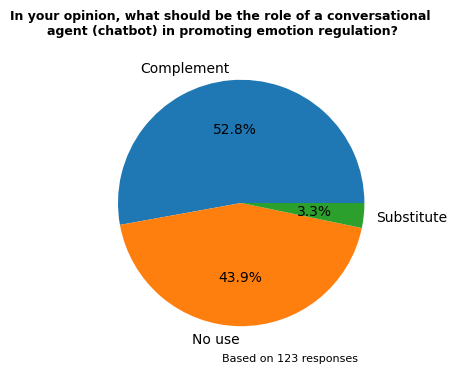

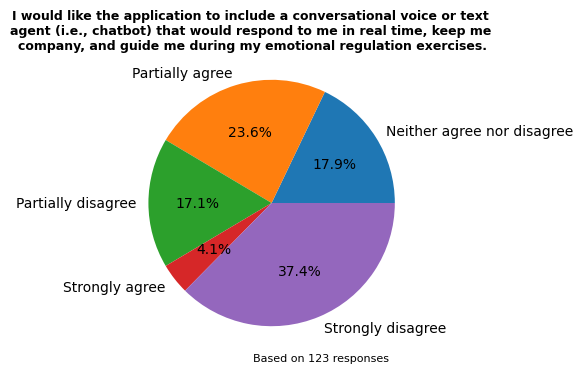

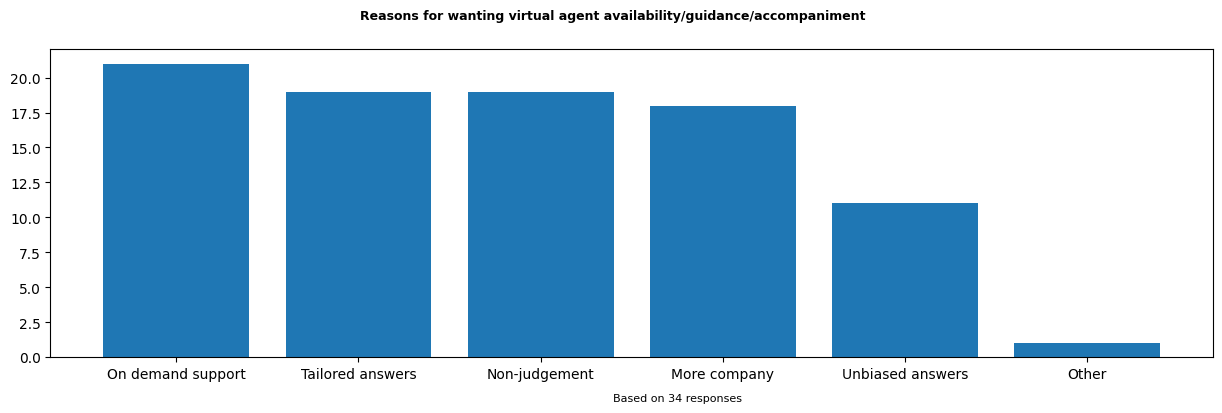

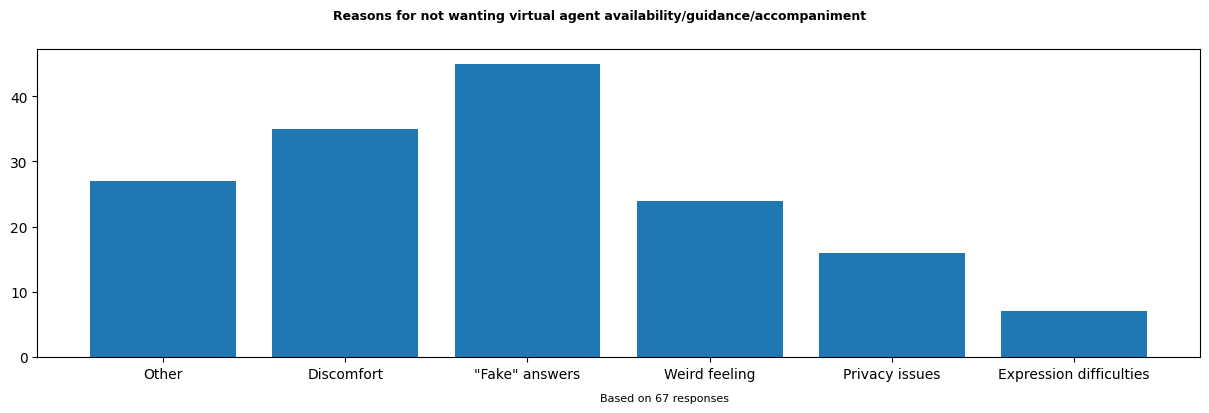

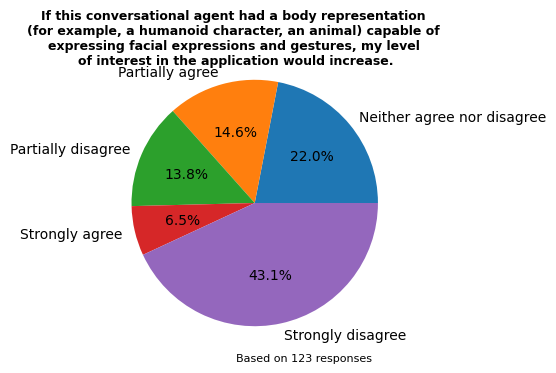

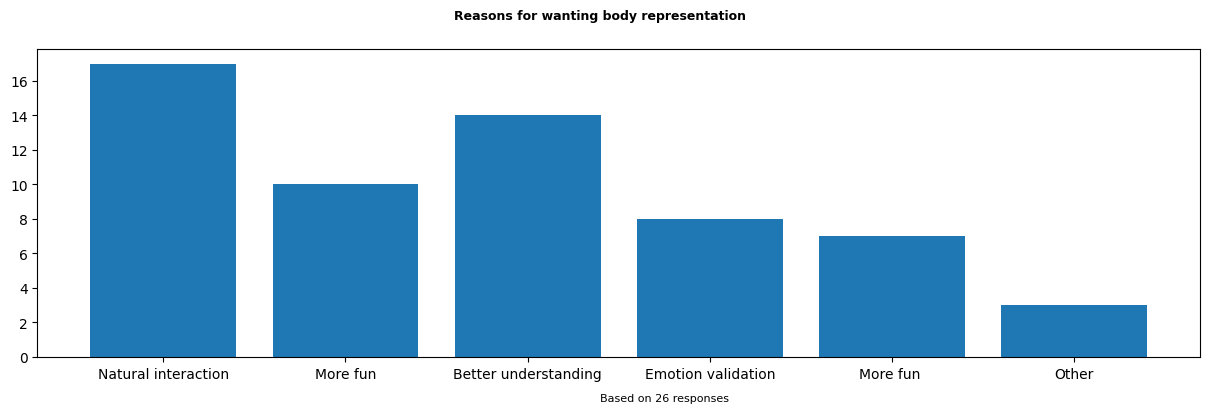

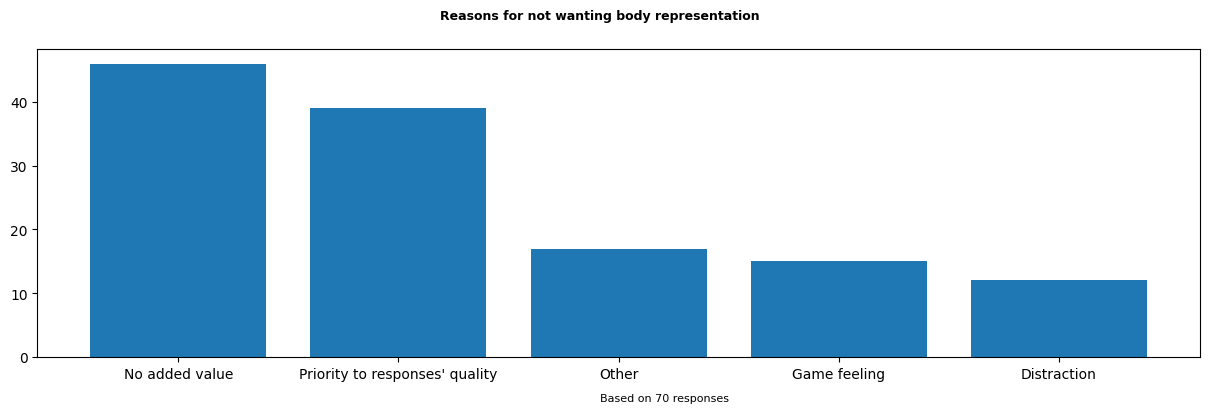

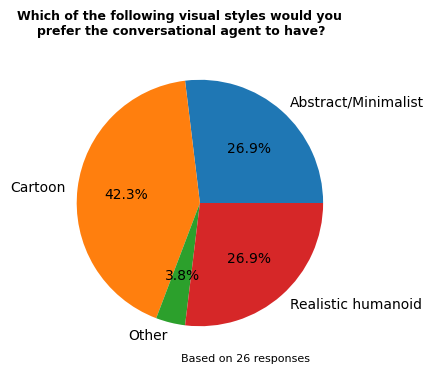

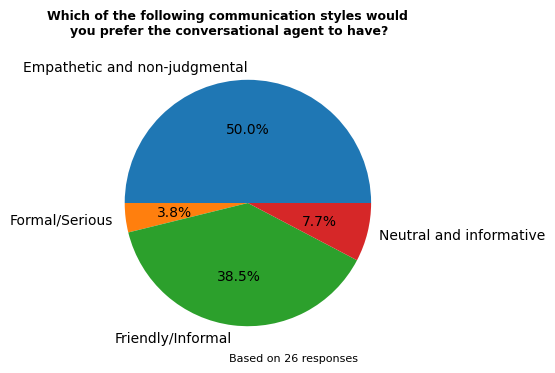

In [ ]:
aa_role = {
    'role': ('AA_role', 'pie', 'In your opinion, what should be the role of a conversational \nagent (chatbot) in promoting emotion regulation?'),
    'include': ('AA_include?', 'pie', 'I would like the application to include a conversational voice or text \nagent (i.e., chatbot) that would respond to me in real time, keep me \ncompany, and guide me during my emotional regulation exercises.'),
    'yes_why': ('If yes, why?', 'bar', 'Reasons for wanting virtual agent availability/guidance/accompaniment'),
    #'yes_why_text': 'If yes, why?_6_TEXT',
    'no_why': ('If not, why?', 'bar', 'Reasons for not wanting virtual agent availability/guidance/accompaniment'),
    # 'no_why_text': 'If not, why?_6_TEXT',
 }

aa_embodied = {
    'body_likert': ('AA embodied_include?', 'pie', 'If this conversational agent had a body representation \n(for example, a humanoid character, an animal) capable of \nexpressing facial expressions and gestures, my level \nof interest in the application would increase.'),
    'yes_why': ('If yes, why?.1', 'bar', 'Reasons for wanting body representation'),
    #'yes_why_text': 'If yes, why?_5_TEXT',
    'no_why': ('If not, why?.1', 'bar', 'Reasons for not wanting body representation'),
    # 'no_why_text': 'If not, why?_5_TEXT',
 }

appearance = {
    'app': ('Appearance', 'pie', 'Which of the following visual styles would you \nprefer the conversational agent to have?'),
    #'app_text': 'Appearance_5_TEXT',
}

comm_style = {
    'comm': ('Communication style.1', 'pie', 'Which of the following communication styles would \nyou prefer the conversational agent to have?'),
    #'comm_text': 'Communication style_6_TEXT',
}

def split_compound_responses(data):
    data_dict = {}
    value_counts = data.value_counts()
    for entry in value_counts.index:
        keys = entry.split(',')
        for key in keys:
            if not (key in data_dict.keys()):
                data_dict[key] = 0
    # print(data_dict)

    for entry in data:
        if type(entry) == str:
            keys = entry.split(',')
            for key in keys:
                data_dict[key] += 1

    return data_dict

questions_array = [aa_role, aa_embodied, appearance, comm_style]
for question in questions_array:
    for figure in question.keys():
        fig, ax = plt.subplots(figsize=(15, 4))
        data = df[question[figure][0]].value_counts().sort_index()

        if question[figure][1] == 'bar':
            # print(question[figure][2])
            # print(question[figure][1])
            # print(data.index)
            # print(data)
            data_dict = split_compound_responses(df[question[figure][0]])

            ax.bar(data_dict.keys(), data_dict.values())
            plt.figtext(0.5, 0.0, f"Based on {sum(data)} responses", fontsize=8)
        elif question[figure][1] == 'pie':
            ax.pie(data, labels=data.index, autopct='%1.1f%%')
            plt.figtext(0.5, 0.1, f"Based on {sum(data)} responses", fontsize=8)
        fig.suptitle(question[figure][2], fontsize=9, fontweight='bold')
        plt.show()

In [ ]:
#Split by gender
df_m = df[df['Gender'] =='Man']
df_m.name = 'Man'
df_w = df[df['Gender'] =='Woman']
df_w.name = 'Woman'
df_x = df[df['Gender'] =='Non-binary']
df_x.name = 'Non-binary'
dfs = [df_m, df_w, df_x]

#Calculate statistics
nominal = ['AA_role', 'Appearance', 'Communication style.1']
compound_nominal = ['If yes, why?', 'If not, why?', 'If yes, why?.1', 'If not, why?.1']
ordinal = ['AA_include?', 'AA embodied_include?']

for dv in nominal:
    contingency_df = df_m[dv].value_counts().sort_index().rename(df_m.name).to_frame()
    for split_df in dfs[1:]:
        contingency_df = contingency_df.join(split_df[dv].value_counts().sort_index().rename(split_df.name).to_frame(), how='left')
    contingency_df = contingency_df.fillna(0)
    display(contingency_df.head())
    chisquare = scipy.stats.chisquare(contingency_df, axis=None)
    print(f"Chi-square statistic for {dv}: {chisquare.statistic}")
    print(f"Chi-square p-value for {dv}: {chisquare.pvalue}")


,Man,Woman,Non-binary
AA_role,,,
Complement,25,38,2.0
No use,22,27,5.0
Substitute,2,2,0.0


Chi-square statistic for AA_role: 119.85365853658539
Chi-square p-value for AA_role: 3.5541675133400793e-22


,Man,Woman,Non-binary
Appearance,,,
Abstract/Minimalist,2,5.0,0.0
Cartoon,4,7.0,0.0
Other,1,0.0,0.0
Realistic humanoid,2,5.0,0.0


Chi-square statistic for Appearance: 31.230769230769237
Chi-square p-value for Appearance: 0.0010123064202843836


,Man,Woman,Non-binary
Communication style.1,,,
Empathetic and non-judgmental,4,9,0.0
Friendly/Informal,4,6,0.0
Neutral and informative,1,1,0.0


Chi-square statistic for Communication style.1: 29.360000000000007
Chi-square p-value for Communication style.1: 0.0002741155250942536
